In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/my-data/data/CLEVRTEX_full_022936.png
/kaggle/input/my-data/data/CLEVRTEX_full_022646.png
/kaggle/input/my-data/data/CLEVRTEX_full_022003.png
/kaggle/input/my-data/data/CLEVRTEX_full_022353.png
/kaggle/input/my-data/data/CLEVRTEX_full_022517.png
/kaggle/input/my-data/data/CLEVRTEX_full_022870.png
/kaggle/input/my-data/data/CLEVRTEX_full_022475.png
/kaggle/input/my-data/data/CLEVRTEX_full_022695.png
/kaggle/input/my-data/data/CLEVRTEX_full_022495.png
/kaggle/input/my-data/data/CLEVRTEX_full_022933.png
/kaggle/input/my-data/data/CLEVRTEX_full_022086.png
/kaggle/input/my-data/data/CLEVRTEX_full_022030.png
/kaggle/input/my-data/data/CLEVRTEX_full_022507.png
/kaggle/input/my-data/data/CLEVRTEX_full_022541.png
/kaggle/input/my-data/data/CLEVRTEX_full_022713.png
/kaggle/input/my-data/data/CLEVRTEX_full_022623.png
/kaggle/input/my-data/data/CLEVRTEX_full_022163.png
/kaggle/input/my-data/data/CLEVRTEX_full_022502.png
/kaggle/input/my-data/data/CLEVRTEX_full_022313.png
/kaggle/inpu

In [2]:
# 1. Clone repository
!git clone https://github.com/traananhdat/cobl.git
%cd cobl

# 2. Kiểm tra thư mục
!ls

Cloning into 'cobl'...
remote: Enumerating objects: 180, done.
remote: Counting objects: 100% (180/180), done.
remote: Compressing objects: 100% (138/138), done.
remote: Total 180 (delta 81), reused 113 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (180/180), 7.86 MiB | 19.58 MiB/s, done.
Resolving deltas: 100% (81/81), done.
/kaggle/working/cobl
cobl  demo  install.sh	LICENSE  media	README.md  setup.py


In [3]:
# Cài đặt các thư viện cơ bản thường dùng cho COBL
!pip install torch torchvision torchaudio
!pip install opencv-python-headless pandas matplotlib scikit-learn tqdm

In [4]:
import torch
import torch.nn as nn

class UNetEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU()
        )
        self.pool = nn.MaxPool2d(2)

        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU()
        )

        self.enc3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU()
        )

        self.enc4 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        x = self.enc1(x)
        x = self.enc2(self.pool(x))
        x = self.enc3(self.pool(x))
        x = self.enc4(self.pool(x))
        return x   # Feature map


In [5]:
import cv2
import numpy as np

def load_image(img_path, size=(256, 256)):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    img = img / 255.0
    img = torch.tensor(img).permute(2, 0, 1).unsqueeze(0).float()
    return img


In [6]:
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Thiết bị:", device)

model = UNetEncoder().to(device)
model.eval()

embeddings = {}


Thiết bị: cuda


In [7]:
import os
from tqdm import tqdm

input_dir = "/kaggle/input/my-data/data"  # đường dẫn thư mục ảnh
for img_name in tqdm(os.listdir(input_dir)):
    img_path = os.path.join(input_dir, img_name)

    img = load_image(img_path).to(device)

    with torch.no_grad():
        feature_map = model(img)

    # Global Average Pooling → vector 512 chiều
    embedding = torch.mean(feature_map, dim=[2, 3])
    embedding = embedding.squeeze().cpu().numpy()

    embeddings[img_name] = embedding


100%|██████████| 1000/1000 [00:14<00:00, 68.85it/s]


In [8]:
print("Số embedding:", len(embeddings))
first_key = list(embeddings.keys())[0]
print("Tên ảnh:", first_key)
print("Kích thước vector:", embeddings[first_key].shape)


Số embedding: 1000
Tên ảnh: CLEVRTEX_full_022936.png
Kích thước vector: (512,)


In [9]:
import pandas as pd

df = pd.DataFrame.from_dict(embeddings, orient="index")
df.to_csv("embedding.csv")

print("Đã lưu embedding.csv")


Đã lưu embedding.csv


In [10]:
import numpy as np

np.save("embedding.npy", embeddings)
print("Đã lưu embedding.npy")

Đã lưu embedding.npy


Shape embedding: (1000, 512)
Explained variance ratio: [0.91603293 0.04169415]
Silhouette score: 0.4061701437530905


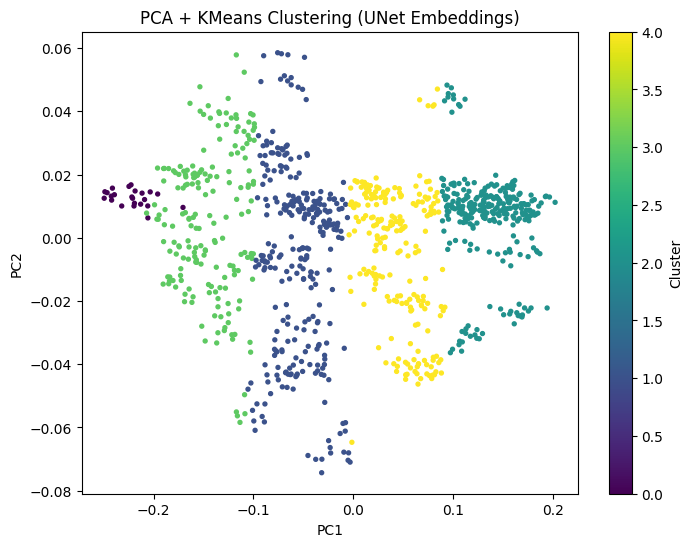

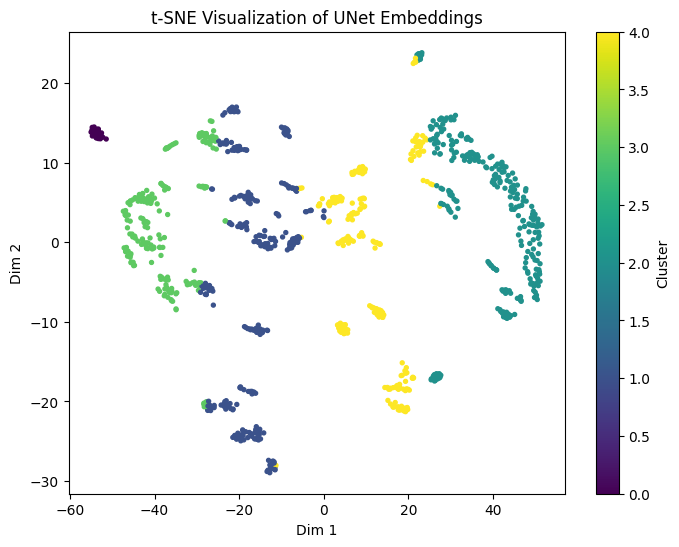

Đã lưu embedding_with_cluster.csv


In [11]:
# =========================
# 1. IMPORT THƯ VIỆN
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

# =========================
# 2. LOAD EMBEDDING
# =========================
df = pd.read_csv("embedding.csv", index_col=0)
print("Shape embedding:", df.shape)

X = df.values  # (N, 512)

# =========================
# 3. PCA (512 → 2)
# =========================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Explained variance ratio:", pca.explained_variance_ratio_)

# =========================
# 4. KMEANS CLUSTERING
# =========================
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(X)

# =========================
# 5. SILHOUETTE SCORE
# =========================
sil_score = silhouette_score(X, labels)
print("Silhouette score:", sil_score)

# =========================
# 6. PLOT PCA + CLUSTER
# =========================
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=8)
plt.title("PCA + KMeans Clustering (UNet Embeddings)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.show()

# =========================
# 7. t-SNE VISUALIZATION
# =========================
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, s=8)
plt.title("t-SNE Visualization of UNet Embeddings")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.colorbar(label="Cluster")
plt.show()

# =========================
# 8. LƯU KẾT QUẢ CLUSTER
# =========================
df_result = df.copy()
df_result["cluster"] = labels
df_result.to_csv("embedding_with_cluster.csv")

print("Đã lưu embedding_with_cluster.csv")


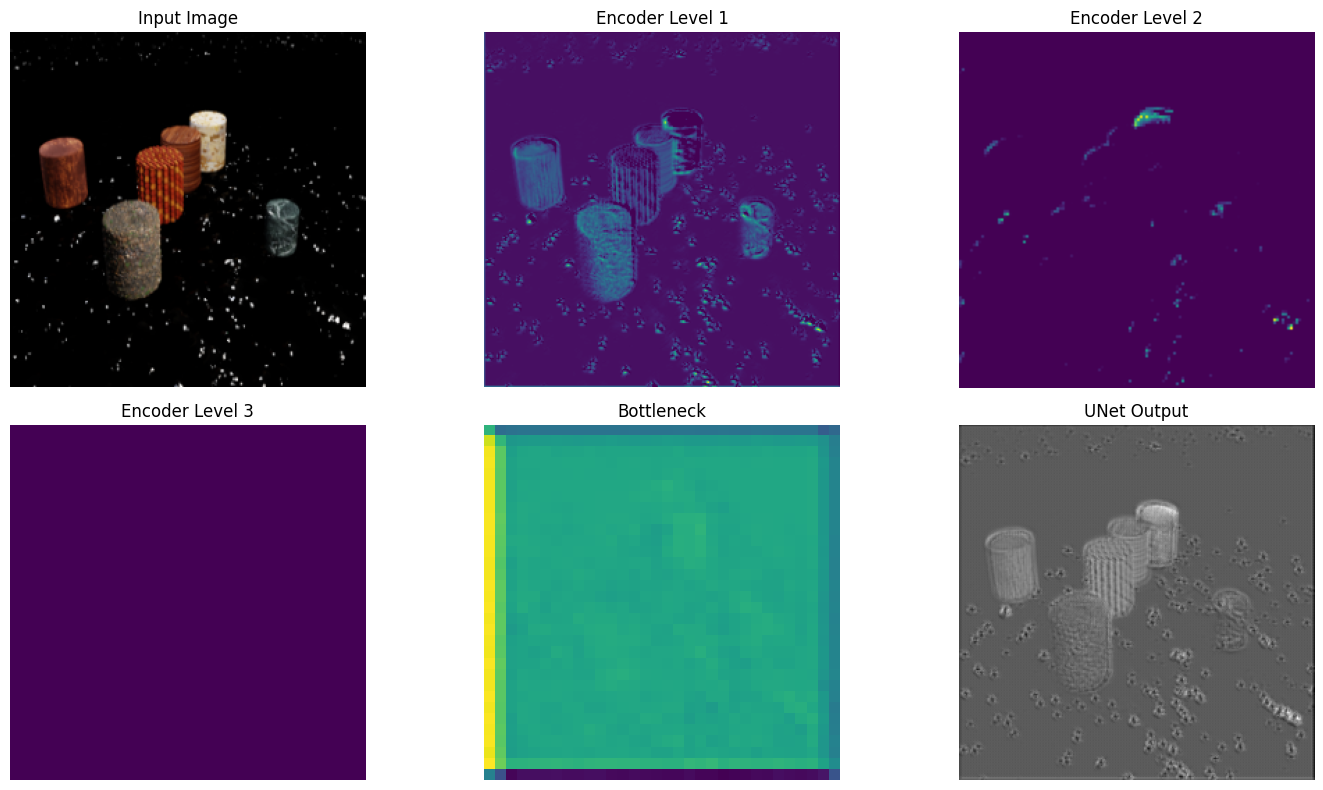

In [12]:
# =========================
# 1. IMPORT
# =========================
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch import nn

# =========================
# 2. LOAD 1 ẢNH INPUT
# =========================
input_dir = "/kaggle/input/my-data/data"
img_name = os.listdir(input_dir)[0]
img_path = os.path.join(input_dir, img_name)

def load_image(path, size=256):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    img_norm = img / 255.0
    tensor = torch.tensor(img_norm, dtype=torch.float32).permute(2,0,1)
    return tensor.unsqueeze(0), img

img_tensor, img_raw = load_image(img_path)

# =========================
# 3. UNET MODEL
# =========================
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU()
        )
    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.e1 = DoubleConv(3, 64)
        self.e2 = DoubleConv(64, 128)
        self.e3 = DoubleConv(128, 256)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, 2)
        self.d3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.d2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.d1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        b  = self.bottleneck(self.pool(e3))

        d3 = self.d3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.d2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.d1(torch.cat([self.up1(d2), e1], dim=1))

        out = torch.sigmoid(self.out(d1))
        return out, e1, e2, e3, b

# =========================
# 4. RUN MODEL
# =========================
device = "cuda" if torch.cuda.is_available() else "cpu"
model = UNet().to(device)
model.eval()

img_tensor = img_tensor.to(device)

with torch.no_grad():
    output, e1, e2, e3, bottleneck = model(img_tensor)

# =========================
# 5. HIỂN THỊ KẾT QUẢ
# =========================
plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(img_raw)
plt.title("Input Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(e1[0,0].cpu(), cmap="viridis")
plt.title("Encoder Level 1")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(e2[0,0].cpu(), cmap="viridis")
plt.title("Encoder Level 2")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(e3[0,0].cpu(), cmap="viridis")
plt.title("Encoder Level 3")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(bottleneck[0,0].cpu(), cmap="viridis")
plt.title("Bottleneck")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(output[0,0].cpu(), cmap="gray")
plt.title("UNet Output")
plt.axis("off")

plt.tight_layout()
plt.show()
